![Alt text](https://imgur.com/orZWHly.png=80)
source: @allison_horst https://github.com/allisonhorst/penguins

You have been asked to support a team of researchers who have been collecting data about penguins in Antartica! The data is available in csv-Format as `penguins.csv`

**Origin of this data** : Data were collected and made available by Dr. Kristen Gorman and the Palmer Station, Antarctica LTER, a member of the Long Term Ecological Research Network.

**The dataset consists of 5 columns.**

Column | Description
--- | ---
culmen_length_mm | culmen length (mm)
culmen_depth_mm | culmen depth (mm)
flipper_length_mm | flipper length (mm)
body_mass_g | body mass (g)
sex | penguin sex

Unfortunately, they have not been able to record the species of penguin, but they know that there are **at least three** species that are native to the region: **Adelie**, **Chinstrap**, and **Gentoo**.  Your task is to apply your data science skills to help them identify groups in the dataset!

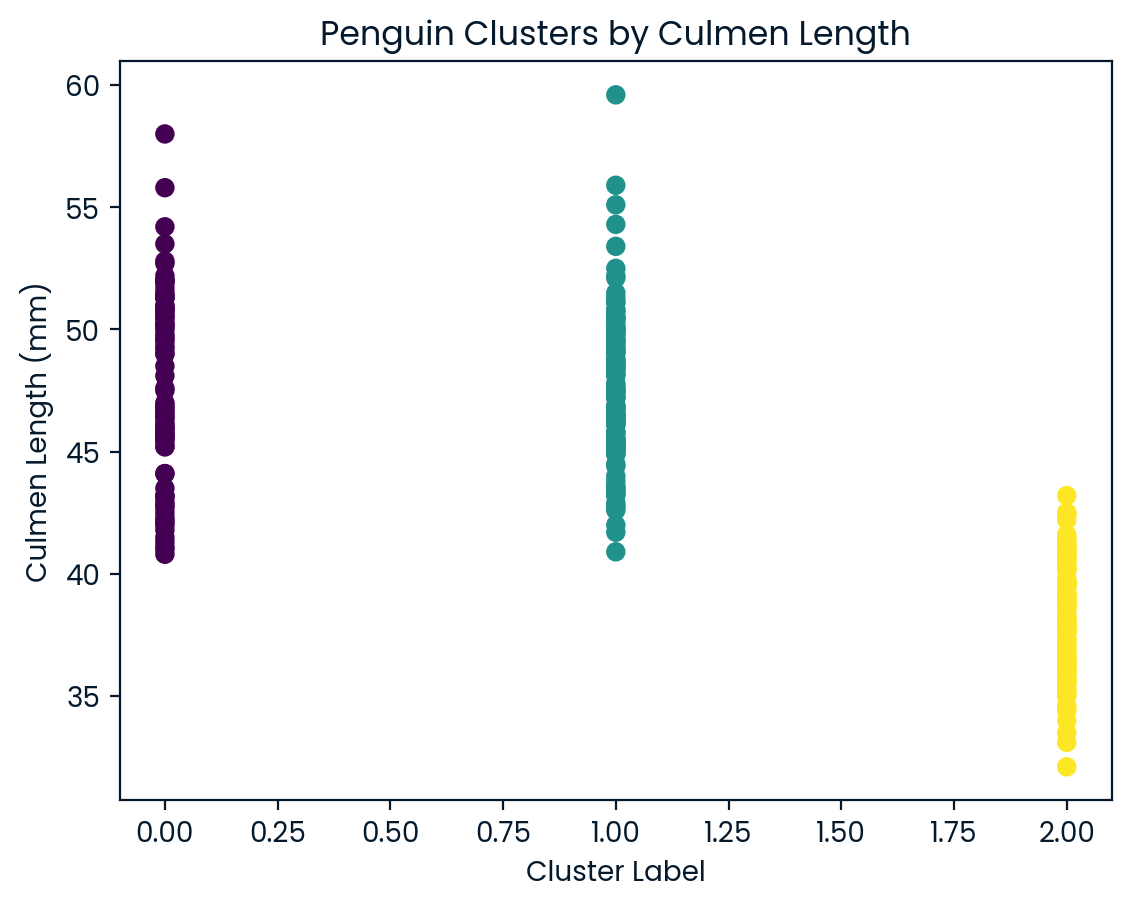

       culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
label                                                                   
0             47.662353        18.748235         196.917647  3898.235294
1             47.568067        14.996639         217.235294  5092.436975
2             38.305469        18.098437         188.554688  3587.500000


In [12]:
# Import Required Packages
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Loading and examining the dataset
penguins_df = pd.read_csv("penguins.csv")
penguins_df.head()

# preprocess dataset to create a dummy variable
samples = penguins_df.drop('sex', axis=1)
scaler = StandardScaler()
samples_scaled = scaler.fit_transform(samples)


# detect the optimal number of clusters for kmeans
# elbow analysis

inertias = []

ks = range(1,10)

for k in ks:
    model = KMeans(n_clusters = k, random_state=42).fit(samples_scaled)
    inertias.append(model.inertia_)

plt.plot(ks, inertias, '-o')
plt.xlabel('Number of clusters, k')
plt.ylabel('Inertia')
plt.xticks(ks)
plt.show

# rerunning kmeans with optimal cluster
model = KMeans(n_clusters=3, random_state=42).fit(samples_scaled)
penguins_df['label'] = model.labels_

plt.clf()
plt.scatter(
    penguins_df['label'],
    penguins_df['culmen_length_mm'],
    c=model.labels_
)

plt.xlabel('Cluster Label')
plt.ylabel('Culmen Length (mm)')
plt.title('Penguin Clusters by Culmen Length')
plt.show()

# final statistical DataFrame
numeric_columns = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
penguins_df['label'] = model.labels_
stat_penguins = penguins_df.groupby('label')[numeric_columns].mean()

print(stat_penguins)